# Fully Supervised with Linear Embeddings
# TypiClust

## Prerequisites

In [29]:
import numpy as np
import pandas as pd
import torch
import torchvision, torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

In [2]:
# checking if the GPU is enabled
print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

False


In [3]:
# using Google Drive to save checkpoints
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## K-Means Algorithm

In [23]:
def kmeans(embeddings, num_clusters):
    if num_clusters <= 50: # using KMeans when K <= 50, and MiniBatch otherwise..
        km = KMeans(n_clusters=num_clusters)
        km.fit_predict(embeddings)
    else:
        km = MiniBatchKMeans(n_clusters=num_clusters, batch_size=5000)
        km.fit_predict(embeddings)
    return km.labels_ # 1D array of integers

## Typicality Calculation
- the inverse of the average Euclidean distance to its K nearest neighbours

In [11]:
def calculate_typicality(embed, num_neighbors=20): # 20 as mentioned in the paper
    # Get the k nearest neighbors
    nbrs = NearestNeighbors(n_neighbors=num_neighbors + 1).fit(embed)
    distances, _ = nbrs.kneighbors(embed)

    # Exclude the first neighbor (the point itself, distance = 0)
    distances = distances[:, 1:]

    mean_squared_distance = np.mean(distances ** 2, axis=1)
    typicality = 1 / (mean_squared_distance + 1e-5)

    return typicality

## Queries

In [12]:
def query_selection(embeddings, init_clusters, lSet, B):
    covered = set(cluster_assignments[i] for i in lSet)

    # Count sizes of uncovered clusters, filter out small ones, take B as the largest cluster
    unique, counts = np.unique(init_clusters, return_counts=True)
    cluster_sizes = dict(zip(unique, counts))

    selected_clusters = sorted(
        [c for c in cluster_sizes if c not in covered and cluster_sizes[c] >= 5],
        key=lambda c: -cluster_sizes[c]
    )[:B]

    # For each cluster, pick the most typical point
    queries = []
    for cluster_id in selected_clusters:
        cluster_indices = np.where(init_clusters == cluster_id)[0]
        cluster_embs = embeddings[cluster_indices]
        scores = calculate_typicality(cluster_embs, num_neighbors=min(20, len(cluster_embs)))
        queries.append(cluster_indices[np.argmax(scores)])

    return queries

## Loading saved models to be used in linear classifier

In [13]:
# setting up the pretrained simclr model so it can be used in the linear classifier
# would do the same if it was self trained
resnet18 = torchvision.models.resnet18(weights=None, progress=True)
resnet18.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
resnet18.maxpool = nn.Identity()
resnet18.fc = nn.Identity()

class ProjectionHead(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(512, 512)
    self.bn = nn.BatchNorm1d(512)
    self.relu = nn.ReLU(inplace=True)
    self.fc2 = nn.Linear(512, 128)

  def forward(self, x):
    x = self.fc1(x)
    x = self.bn(x)
    x = self.relu(x)
    x = self.fc2(x)
    return F.normalize(x, dim=1)

class SimCLR(nn.Module):
  def __init__(self):
    super().__init__()
    self.encoder = resnet18
    self.projection_head = ProjectionHead()

  def forward(self, x1, x2):
      z1 = self.encoder(x1)
      z2 = self.encoder(x2)

      p1 = self.projection_head(z1)
      p2 = self.projection_head(z2)

      return p1, p2

In [15]:
# load saved simclr model
checkpoint_path_simclr = '/content/drive/MyDrive/5CCSAMLF/FS_Embed/models/simclr_latest.pth'
checkpoint_simclr = torch.load(checkpoint_path_simclr, map_location='cpu')

model_simclr = SimCLR().to(device)
model_simclr.load_state_dict(checkpoint_simclr['model_state_dict'])

<All keys matched successfully>

In [18]:
# load train embeddings
checkpoint_path_train = '/content/drive/MyDrive/5CCSAMLF/FS_Embed/models/train_embeddings.pth'
checkpoint_train = torch.load(checkpoint_path_train, map_location='cpu')

train_embeddings = checkpoint_train['embeddings']
train_labels = checkpoint_train['labels']

In [20]:
# load test embeddings
checkpoint_path_test = '/content/drive/MyDrive/5CCSAMLF/FS_Embed/models/test_embeddings.pth'
checkpoint_test = torch.load(checkpoint_path_test, map_location='cpu')

test_embeddings = checkpoint_test['embeddings']
test_labels = checkpoint_test['labels']

## Training Linear Classifier for Evaluation

In [21]:
# Define train/evaluation loop to evaluate TCP_RP AL strategy
def train_and_evaluate(lSet, num_epochs=260):

    X_train = train_embeddings[lSet].to(device)
    y_train = train_labels[lSet].to(device)

    X_test = test_embeddings.to(device)
    y_test = test_labels.to(device)

    # d x C
    # C = number of classes
    linear = nn.Linear(512, 10).to(device)

    optimiser = torch.optim.SGD(linear.parameters(), lr=2.5, momentum=0.9, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=260) # trained around 130 epochs before stopping
    criterion = nn.CrossEntropyLoss()

    linear.train()
    for epoch in range(num_epochs):
        optimiser.zero_grad()
        outputs = linear(X_train)
        loss = criterion(outputs, y_train)

        loss.backward()
        optimiser.step()

        scheduler.step()

    # Evaluate on test set
    linear.eval()
    with torch.no_grad():
        test_outputs = linear(X_test)
        preds = test_outputs.argmax(dim=1)
        acc = (preds == y_test).float().mean().item() * 100
    return acc

## Evaluating against budget and accuracy

In [28]:
budgets = []
accuracy_typiclust = []
accuracy_random = []

labelled_indices = []
random_indices = [] # for random baseline strat
B = 10

train_embeddings_np = train_embeddings.numpy()

for iteration in range(6): #60 -> then budget is exhausteddd
    K = min(len(labelled_indices) + B, 500)
    cluster_assignments = kmeans(train_embeddings_np, K)
    new_queries = query_selection(train_embeddings_np, cluster_assignments, labelled_indices, B)
    labelled_indices.extend([int(q) for q in new_queries])

    # Random baseline - same budget, random selection
    all_indices = list(range(len(train_labels)))
    available = [i for i in all_indices if i not in random_indices]
    random_indices.extend(np.random.choice(available, B, replace=False).tolist())

    # Get accuracies
    acc_typi = train_and_evaluate(labelled_indices)
    acc_rand = train_and_evaluate(random_indices)

    budgets.append(len(labelled_indices))
    accuracy_typiclust.append(acc_typi)
    accuracy_random.append(acc_rand)

    print(f"Iter. {iteration+1} | Budget = {len(labelled_indices)} | "
          f"TPC_RP: {acc_typi:.1f} % | Random: {acc_rand:.1f} %")

Iter. 1 | Budget = 10 | TPC_RP: 49.3 % | Random: 32.3 %
Iter. 2 | Budget = 20 | TPC_RP: 52.7 % | Random: 36.1 %
Iter. 3 | Budget = 30 | TPC_RP: 61.9 % | Random: 45.8 %
Iter. 4 | Budget = 40 | TPC_RP: 64.1 % | Random: 50.2 %
Iter. 5 | Budget = 50 | TPC_RP: 67.0 % | Random: 53.9 %
Iter. 6 | Budget = 60 | TPC_RP: 70.0 % | Random: 59.9 %


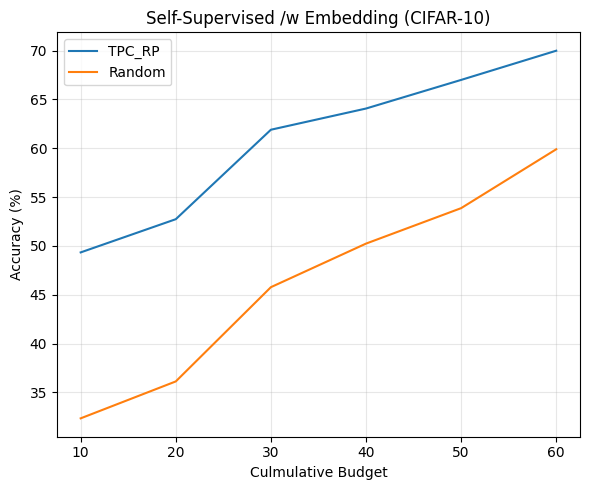

In [31]:
# plotting graph
x = budgets
y1 = accuracy_typiclust
y2 = accuracy_random

plt.figure(figsize=(6, 5))
plt.plot(x, y1, label = 'TPC_RP')
plt.plot(x, y2, label = 'Random')
plt.ylabel('Accuracy (%)')
plt.xlabel('Culmulative Budget')
plt.title('Fully Supervised /w Self-Supervised Embedding (CIFAR-10)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()

plt.savefig('results.png', format='png')
plt.savefig('results.svg', format='svg')

plt.show()